In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Utilizaremos torchvision para descargar el conjunto de datos MNIST

In [2]:
# Definir las transformaciones (normalización de los datos)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convertir las imágenes a tensores, convertimos las imágenes a tensores de tamaña 1x28x28
    transforms.Normalize((0.5,), (0.5,))  # Normalizar, esto lo hacemos porque las imágenes tienen una escala en la que 255 es blanco y 0 es negro, de forma que lo normalizamos a unos valores más pequeños para poder entrenarlo de forma más rápida.
    #Los valores que ponemos son la media y la desviación estándar, de forma que cada píxel se le resta la media y se divide entre la desviación estándar
])

# Cargar el conjunto de datos MNIST
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Crear DataLoader para entrenamiento y test
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

Ahora vamos a definir la red neuronal

In [3]:
class SimpleNN(nn.Module):
    def __init__(self): #Método constructor para crear una instancia del modelo, definimos las capas de la red
        super(SimpleNN, self).__init__() #Iniciamos el modelo
        self.flatten = nn.Flatten() #Transformamos la entrada de la imagen en un vector de una sola dimensión.
        self.fc1 = nn.Linear(28 * 28, 128) #Capa fully connected con 128 neuronas, capa conectada o capa densa, esto significa que cada neurona de esta capa esta conectada a la capa oculta
        self.fc2 = nn.Linear(128, 10) #Capa fully connected con 10 neuronas (una por cada clase), ya que clasificamos los números del 0 al 9

    def forward(self, x): #Definimos el método forward para definir el flujo de datos a través de la red
        x = self.flatten(x) #Aplanamos la imagen de entrada
        x = torch.relu(self.fc1(x)) #Aplicamos la función de activación ReLU a la salida de la primera capa, convertimos todos los valores negavtivos a 0 y los positivos quedan como estan
        x = self.fc2(x) #Obtenemos la salida de la segunda capa
        return x
    


Ahora iniciamos el modelo, la función de pérdida y el optimizador

In [4]:
model = SimpleNN()


for name, param in model.named_parameters():
    print(name, param.shape)

#Establecemos la funciónd de pérdida
criterion = nn.CrossEntropyLoss() #Función de pérdida para clasificación, esta función combina la función de activación softmax con la función de pérdida de entropía cruzada, lo que es adecuado para problemas de clasificación multiclase.

#Establecemos el optimizador
#Utilizaremos Adam
optimizer = torch.optim.Adam(model.parameters(),lr=0.001) #Optimizador Adam, este optimizador es una extensión de SGD que adapta la tasa de aprendizaje para cada parámetro, lo que puede acelerar el entrenamiento y mejorar la convergencia.
#Lo pongo alto para hacer pruebas

fc1.weight torch.Size([128, 784])
fc1.bias torch.Size([128])
fc2.weight torch.Size([10, 128])
fc2.bias torch.Size([10])


El siguiente paso es entrenar el modelo

In [5]:
#Antes de nada hay que definir el entrenamiento
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(trainset.data,trainset.targets,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print (y_train.shape)
print(X_train.dtype)
print(y_train.dtype)

torch.Size([48000, 28, 28])
torch.Size([48000])
torch.uint8
torch.int64


Epoch [5/10], Loss Train: 0.0567, Loss Test: 0.0019
Epoch [10/10], Loss Train: 0.1763, Loss Test: 0.0001


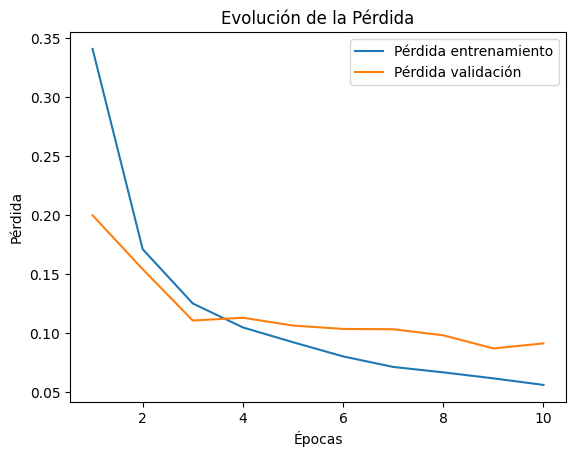

In [7]:
# Listas para almacenar las pérdidas
train_loss = []  # Lista para la pérdida de entrenamiento
val_loss = []    # Lista para la pérdida de validación

num_epochs = 10  # Número de épocas (iteraciones)
for epoch in range(num_epochs):
    model.train()  # Modo entrenamiento
    running_loss = 0.0
    for inputs, labels in trainloader:  # Recorrer todos los datos de entrenamiento
        optimizer.zero_grad()  # Resetear los gradientes
        
        # Pasar los datos por el modelo
        outputs = model(inputs)
        
        # Calcular la pérdida
        loss = criterion(outputs, labels)
        
        loss.backward()  # Retropropagar el error
        optimizer.step()  # Actualizar los pesos
        
        running_loss += loss.item()  # Acumular la pérdida de entrenamiento

    train_loss.append(running_loss / len(trainloader))  # Guardar la media de la pérdida de entrenamiento

    # Validación
    model.eval()  # Modo evaluación
    val_running_loss = 0.0
    with torch.no_grad():  # Desactivamos los gradientes
        for inputs, labels in testloader:  # Recorrer todos los datos de prueba
            val_outputs = model(inputs)
            val_loss_val = criterion(val_outputs, labels)
            val_running_loss += val_loss_val.item()  # Acumular la pérdida de validación

    val_loss.append(val_running_loss / len(testloader))  # Guardar la media de la pérdida de validación

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss Train: {loss.item():.4f}, Loss Test: {val_loss_val.item():.4f}')

# Graficar las pérdidas
plt.plot(range(1, num_epochs+1), train_loss, label="Pérdida entrenamiento")
plt.plot(range(1, num_epochs+1), val_loss, label="Pérdida validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()
plt.show()